# Bayesian Experimental Design

This demo shows how to use the BayesUncertaintyOptimization class for Bayesian Experimental Design for sequensial sampling.

Function to sample: 

$y = x \sin(2 x) + \epsilon$  
$\frac{dy}{dx} = \sin(2 x) + 2 x \cos(2 x) + \epsilon$

Where the function and derivative observations have white noise with variance $\epsilon \sim \mathcal{N}(0, 0.2)$.

In [1]:
import sys 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import h5py

from multiprocessing import Pool, cpu_count

from sklearn.metrics import mean_squared_error

sys.path.append("../../../gpder")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware
from gpder.bayes import BayesUncertaintyOptimization

from plotting_utils import plot_gp_evolution
from plotting_utils import get_mse_uncert

In [2]:
def F(X, e=0.2):
    noise = np.random.normal(0, e, X.shape)
    return X * np.sin(2 * X) + noise

def dF(X, e=0.2):
    noise = np.random.normal(0, e, X.shape)
    return np.sin(2 * X) + 2 * X * np.cos(2 * X) + noise

In [3]:
np.random.seed(123)
X_lower, X_upper = -2*np.pi, 2*np.pi

# -- testing points -- #
X_test = np.linspace(X_lower, X_upper, 100).reshape(-1, 1)
dX_test = X_test

y_test_nonoise = F(X_test, e=0)
dy_test_nonoise = dF(dX_test, e=0)
y_test = F(X_test)
dy_test = dF(dX_test)

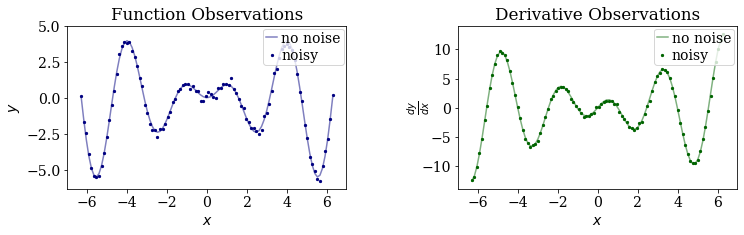

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "14"

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(X_test, y_test_nonoise, alpha=0.5, color='navy', label='no noise')
ax[0].scatter(X_test, y_test, color='navy', s=5, label='noisy')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
ax[0].set_yticks([-5, -2.5, 0, 2.5, 5])
ax[0].set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax[0].set_title('Function Observations')
ax[0].tick_params(axis='both', which='major')

ax[1].plot(dX_test, dy_test_nonoise, alpha=0.5, color='darkgreen', label='no noise')
ax[1].scatter(dX_test, dy_test, color='darkgreen', s=5, label='noisy')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$\frac{dy}{dx}$', labelpad=-10)
ax[1].set_yticks([-10, -5, 0, 5, 10])
ax[1].set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax[1].set_title('Derivative Observations')
ax[1].tick_params(axis='both', which='major')

ax[0].legend(labelspacing=0.2, handlelength=0.8, 
             borderaxespad=0.2, handletextpad=0.3, borderpad=0.2,
             loc='upper right')
ax[1].legend(labelspacing=0.2, handlelength=0.8, 
             borderaxespad=0.2, handletextpad=0.3, borderpad=0.2,
             loc='upper right')
plt.show()

## Regular GPR

Five initial experiments are observed and used to train a GP regressor. 

BayesUncertaintyOptimization is used to sequentially select the next best 10 sampling points. 

In [5]:
np.random.seed(123)
# -- training points -- #
X_train = np.random.uniform(X_lower, X_upper, 5).reshape(-1, 1)
# X_train = np.linspace(X_lower, X_upper, 5).reshape(-1, 1)
y_train = F(X_train)

In [6]:
kernel = GPKernel(constant_value_bounds=(0.1, 1.5), 
                  length_scale_bounds=(0.5, 1.5), 
                  noise_level_bounds=(1e-4, 1e-1))
gp_regular = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30)
gp_regular.fit(X_train, y_train)
print("Kernel: ", gp_regular.kernel_)
gp_regular.optimizer=None              # Freeze the kernel

params_dicc = {'X': (X_lower, X_upper)}
bayes_reg = BayesUncertaintyOptimization(
    fun=F,                           # Function to sample
    gp=gp_regular,                   # GPR used in the search
    verbose=True,                    # If True, a print-out is printed at every iteration
    param_bounds=params_dicc,        # dicc={'param_name': (lower_bound, upper_bound)}
    random_state=123,                # Random state seed
    )

bayes_reg.minimize_uncertainty(
    X_init=X_train, y_init=y_train,
    X_query=X_test,
    acquisition_opt='trace',
    n_iters=5,                # No. of bayes_regian iterations
    n_minimizer_restarts=20,   # No. of times to restart the minimizer
    )

Kernel:  1.5 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.1)
| Iter | X         | Target     |
| 0    | 2.468905  | -2.342021  |
| 0    | -2.687452 | -2.129218  |
| 0    | -3.432486 | 1.845370   |
| 0    | 0.644840  | 1.015398   |
| 0    | 2.757928  | -2.238455  |
| 1    | 4.821467  | -1.266298  |
| 2    | -5.139978 | -4.024496  |
| 3    | -1.016451 | 0.971325   |
| 4    | 3.829085  | 3.678404   |
| 5    | 5.805365  | -4.901848  |


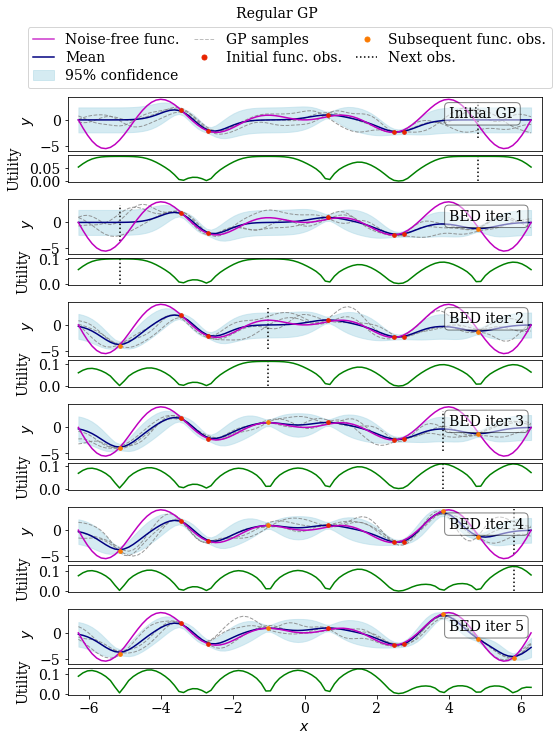

In [7]:
plot_gp_evolution(bayes_reg, 5, X_test, y_test_nonoise)

## Derivative GPR

We now include derivative observations.  
For comparison, we use the same kernel hyperparameters that we used in the regular case. 

In [8]:
# -- training points -- #
dX_train = X_train
dy_train = dF(dX_train)

In [9]:
kernel = GPKernelDerAware(constant_value=gp_regular.kernel_.constant_value, 
                          constant_value_bounds="fixed",
                          length_scale=gp_regular.kernel_.length_scale, 
                          length_scale_bounds="fixed",
                          noise_level=gp_regular.kernel_.noise_level, 
                          noise_level_bounds="fixed",
                          noise_level_dX_bounds=(1e-3, 1e-1))
gp_deriv = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30)
gp_deriv.fit(X_train, y_train, dX_train, dy_train)
print("Kernel: ", gp_deriv.kernel_)
gp_deriv.optimizer=None              # Freeze the kernel 

bayes_der = BayesUncertaintyOptimization(
    fun=F,                           # Function to minimize the uncertainty of
    dfun=dF,                         # Function to minimize the uncertainty of
    gp=gp_deriv,                     # GPR used in the search
    verbose=True,                    # If True, a print-out is printed at every iteration
    param_bounds=params_dicc,        # dicc={'param_name': (lower_bound, upper_bound)}
    random_state=123,                # Random state seed
    )

bayes_der.minimize_uncertainty(
    X_init=X_train, y_init=y_train, 
    dX_init=X_train, dy_init=dy_train.reshape(-1, 1),
    X_query=X_test,
    acquisition_opt='trace',
    n_iters=5,                # No. of bayes_derian iterations
    n_minimizer_restarts=20,   # No. of times to restart the minimizer
    )

Kernel:  1.5 * DerivativeRBF(length_scale=0.5) + WhiteKernel_X(noise_level=0.1) + WhiteKernel_dX(noise_level=0.1)
| Iter | X         | Target     |
| 0    | 2.468905  | -2.342021  |
| 0    | -2.687452 | -2.129218  |
| 0    | -3.432486 | 1.845370   |
| 0    | 0.644840  | 1.015398   |
| 0    | 2.757928  | -2.238455  |
| 1    | 4.915775  | -1.796359  |
| 2    | -5.250207 | -4.527529  |
| 3    | -0.997645 | 0.534907   |
| 4    | 3.951387  | 4.111006   |
| 5    | 5.924817  | -4.230872  |


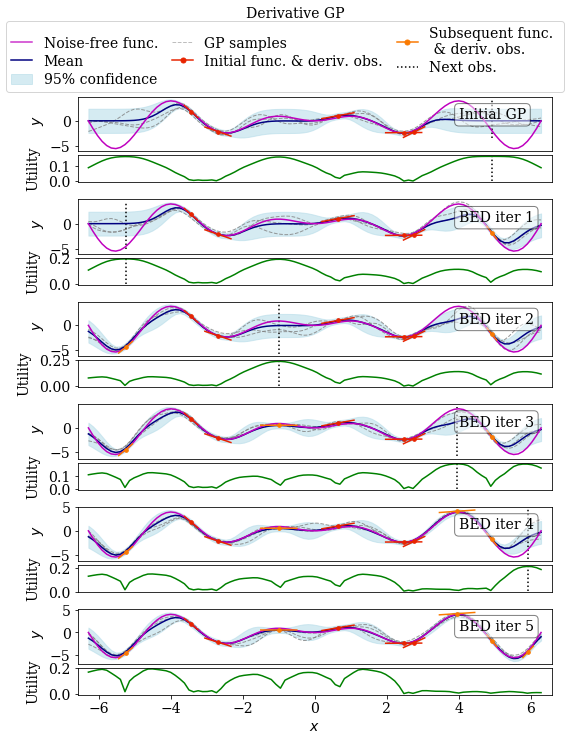

In [10]:
plot_gp_evolution(bayes_der, 5, X_test, y_test_nonoise)